# Mejoras al Modelo

Mejoras respecto al modelo original:
- Se agregan otras categóricas con OHE (Transmission Type, Driven_Wheels, Vehicle Size, Vehicle Style, Engine Fuel Type)
- Market Category expandida en features binarias (Luxury, Performance, etc.)
- Feature engineering: `hp_por_cilindro`, `mpg_combinado`, `antiguedad`
- Modelos adicionales: Lasso, ElasticNet, Random Forest, Gradient Boosting
- Comparación final en test set

In [23]:
#se importa el dataset y se muestran las primeras filas para entender su estructura y contenido.
import pandas as pd
import numpy as np
import os
import warnings
# Se ignoran las advertencias para mantener la salida limpia durante el análisis.
warnings.filterwarnings('ignore')
# Se importan las librerías necesarias para el análisis de datos, la visualización y la construcción de modelos de regresión.
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
# Se busca el archivo 'data.csv' en diferentes ubicaciones posibles y se carga en un DataFrame de pandas.
for _c in ['data.csv', 'notebooks/data.csv', 'ENTREGA/data.csv']:
    if os.path.exists(_c):
        path = _c
        break
# Se muestra la forma del DataFrame y las primeras filas para entender su estructura y contenido.
df = pd.read_csv(path)
print('Shape:', df.shape)
df.head()

Shape: (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 1. Feature Engineering

In [24]:
df = df.copy()

df['log_MSRP'] = np.log1p(df['MSRP'])
df['antiguedad'] = 2024 - df['Year']
df['hp_por_cilindro'] = df['Engine HP'] / df['Engine Cylinders'].replace(0, np.nan)
df['mpg_combinado'] = (df['highway MPG'] + df['city mpg']) / 2

market_tags = ['Luxury', 'Performance', 'High-Performance', 'Factory Tuner',
               'Exotic', 'Crossover', 'Hatchback', 'Diesel', 'Hybrid', 'Flex Fuel']

for tag in market_tags:
    df[f'cat_{tag.lower().replace("-", "_").replace(" ", "_")}'] = (
        df['Market Category'].fillna('').str.contains(tag, case=False).astype(int)
    )

# Tabla resumen de las nuevas features
nuevas_features = {
    'antiguedad':      ('2024 - Year',                          df['antiguedad'].mean()),
    'hp_por_cilindro': ('Engine HP / Engine Cylinders',         df['hp_por_cilindro'].mean()),
    'mpg_combinado':   ('(highway MPG + city mpg) / 2',         df['mpg_combinado'].mean()),
}
resumen_num = pd.DataFrame([
    {'Feature': k, 'Fórmula': v[0], 'Media': round(v[1], 2)}
    for k, v in nuevas_features.items()
])

cat_cols = [c for c in df.columns if c.startswith('cat_')]
resumen_cat = pd.DataFrame([
    {'Feature': c, 'Fórmula': f'Market Category contiene "{c[4:]}"', 'Media (% autos)': f"{df[c].mean()*100:.1f}%"}
    for c in cat_cols
])

print('── Features numéricas derivadas ──')
display(resumen_num)
print('── Features binarias de Market Category ──')
display(resumen_cat)

── Features numéricas derivadas ──


,Feature,Fórmula,Media
0,antiguedad,2024 - Year,13.62
1,hp_por_cilindro,Engine HP / Engine Cylinders,43.77
2,mpg_combinado,(highway MPG + city mpg) / 2,23.19


── Features binarias de Market Category ──


,Feature,Fórmula,Media (% autos)
0,cat_luxury,"Market Category contiene ""luxury""",27.6%
1,cat_performance,"Market Category contiene ""performance""",29.4%
2,cat_high_performance,"Market Category contiene ""high_performance""",11.6%
3,cat_factory_tuner,"Market Category contiene ""factory_tuner""",5.2%
4,cat_exotic,"Market Category contiene ""exotic""",4.2%
5,cat_crossover,"Market Category contiene ""crossover""",17.1%
6,cat_hatchback,"Market Category contiene ""hatchback""",10.1%
7,cat_diesel,"Market Category contiene ""diesel""",1.7%
8,cat_hybrid,"Market Category contiene ""hybrid""",2.9%
9,cat_flex_fuel,"Market Category contiene ""flex_fuel""",10.0%


## 2. División de datos

In [25]:
train_val, test = train_test_split(df, test_size=0.20, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

total = len(df)
resumen_split = pd.DataFrame([
    {'Conjunto': 'train',     'Filas': len(train),     'Proporción': f'{len(train)/total*100:.0f}%', 'Uso': 'Entrenar el modelo'},
    {'Conjunto': 'val',       'Filas': len(val),       'Proporción': f'{len(val)/total*100:.0f}%',   'Uso': 'Ajustar hiperparámetros'},
    {'Conjunto': 'test',      'Filas': len(test),      'Proporción': f'{len(test)/total*100:.0f}%',  'Uso': 'Evaluación final'},
    {'Conjunto': 'TOTAL',     'Filas': total,           'Proporción': '100%',                         'Uso': ''},
])
display(resumen_split)

,Conjunto,Filas,Proporción,Uso
0,train,7148,60%,Entrenar el modelo
1,val,2383,20%,Ajustar hiperparámetros
2,test,2383,20%,Evaluación final
3,TOTAL,11914,100%,


## 3. Preparación de features (pipeline manual)

In [26]:
# Se definen las listas de features numéricas y categóricas, así como las columnas binarias creadas a partir de 'Market Category', para su posterior procesamiento.
numeric_features = [
    'antiguedad', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
    'highway MPG', 'city mpg', 'Popularity',
    'hp_por_cilindro', 'mpg_combinado'
]
# Se definen las features categóricas que serán codificadas mediante OneHotEncoder.
cat_features = [
    'Make', 'Transmission Type', 'Driven_Wheels',
    'Vehicle Size', 'Vehicle Style', 'Engine Fuel Type'
]
# Se identifican las columnas binarias creadas a partir de 'Market Category' para incluirlas como features en el modelo.
market_binary_cols = [c for c in df.columns if c.startswith('cat_')]
# Se muestra un resumen de las features numéricas, categóricas y binarias para verificar su correcta identificación.
imputer = SimpleImputer(strategy='median')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Se procesan las features numéricas con imputación de valores faltantes y las categóricas con codificación one-hot, asegurando que los índices se mantengan para una correcta concatenación posterior.
X_train_num = pd.DataFrame(imputer.fit_transform(train[numeric_features]),
                            columns=numeric_features, index=train.index)
X_val_num   = pd.DataFrame(imputer.transform(val[numeric_features]),
                            columns=numeric_features, index=val.index)
X_test_num  = pd.DataFrame(imputer.transform(test[numeric_features]),
                            columns=numeric_features, index=test.index)
# Se procesan las features categóricas con codificación one-hot, manejando valores faltantes y asegurando que los índices se mantengan para una correcta concatenación posterior.
X_train_cat = pd.DataFrame(encoder.fit_transform(train[cat_features].fillna('desconocido')),
                            columns=encoder.get_feature_names_out(cat_features), index=train.index)
X_val_cat   = pd.DataFrame(encoder.transform(val[cat_features].fillna('desconocido')),
                            columns=encoder.get_feature_names_out(cat_features), index=val.index)
X_test_cat  = pd.DataFrame(encoder.transform(test[cat_features].fillna('desconocido')),
                            columns=encoder.get_feature_names_out(cat_features), index=test.index)
# Se seleccionan las columnas binarias de 'Market Category' y se aseguran los índices para su correcta concatenación posterior.
X_train_mkt = train[market_binary_cols].reset_index(drop=True).set_index(train.index)
X_val_mkt   = val[market_binary_cols].reset_index(drop=True).set_index(val.index)
X_test_mkt  = test[market_binary_cols].reset_index(drop=True).set_index(test.index)
# Se concatenan las features numéricas, categóricas y binarias para formar los conjuntos de entrenamiento, validación y prueba completos, asegurando que los índices se mantengan para una correcta alineación con las etiquetas.
X_train = pd.concat([X_train_num, X_train_cat, X_train_mkt], axis=1)
X_val   = pd.concat([X_val_num,   X_val_cat,   X_val_mkt],   axis=1)
X_test  = pd.concat([X_test_num,  X_test_cat,  X_test_mkt],  axis=1)
# Se extraen las etiquetas de los conjuntos de entrenamiento, validación y prueba, utilizando la transformación logarítmica aplicada previamente a 'MSRP'.
y_train, y_val, y_test = train['log_MSRP'], val['log_MSRP'], test['log_MSRP']
print('Features totales:', X_train.shape[1])

Features totales: 106


## 4. Modelos lineales con regularización

In [27]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
resultados = {}
filas_detalle = []

for ModelClass, nombre in [(Ridge, 'Ridge'), (Lasso, 'Lasso')]:
    scores = []
    for alpha in alphas:
        m = ModelClass(alpha=alpha)
        m.fit(X_train, y_train)
        s = rmse(y_val, m.predict(X_val))
        scores.append(s)
        filas_detalle.append({'Modelo': nombre, 'alpha': alpha, 'RMSE val': round(s, 4)})
    best_alpha = alphas[np.argmin(scores)]
    resultados[nombre] = {'alpha': best_alpha, 'rmse_val': min(scores)}

en_scores = []
for alpha in alphas:
    m = ElasticNet(alpha=alpha, l1_ratio=0.5)
    m.fit(X_train, y_train)
    s = rmse(y_val, m.predict(X_val))
    en_scores.append(s)
    filas_detalle.append({'Modelo': 'ElasticNet', 'alpha': alpha, 'RMSE val': round(s, 4)})
best_alpha_en = alphas[np.argmin(en_scores)]
resultados['ElasticNet'] = {'alpha': best_alpha_en, 'rmse_val': min(en_scores)}

# Tabla detalle por alpha
detalle_df = pd.DataFrame(filas_detalle).pivot(index='alpha', columns='Modelo', values='RMSE val')
print('── RMSE validación por modelo y alpha ──')
display(detalle_df.style.highlight_min(color='lightgreen', axis=0))

# Tabla resumen mejores alphas
resumen_df = pd.DataFrame([
    {'Modelo': k, 'Mejor alpha': v['alpha'], 'RMSE val': round(v['rmse_val'], 4)}
    for k, v in resultados.items()
]).sort_values('RMSE val').reset_index(drop=True)
print('── Mejor alpha por modelo ──')
display(resumen_df.style.highlight_min(subset='RMSE val', color='lightgreen'))

── RMSE validación por modelo y alpha ──


Modelo,ElasticNet,Lasso,Ridge
alpha,,,
0.001000,0.418800,0.421100,0.413100
0.010000,0.450100,0.461100,0.413100
0.100000,0.516600,0.517700,0.413100
1.000000,0.527300,0.542600,0.413400
10.000000,0.830800,0.836300,0.416200
100.000000,0.961000,1.129600,0.429900


── Mejor alpha por modelo ──


,Modelo,Mejor alpha,RMSE val
0,Ridge,0.100000,0.413100
1,ElasticNet,0.001000,0.418800
2,Lasso,0.001000,0.421100


## 5. Random Forest

In [28]:
# Se entrena un modelo de Random Forest con hiperparámetros ajustados, se calcula el RMSE en el conjunto de validación y se almacenan los resultados en el diccionario 'resultados'. Además, se muestran las 10 features más importantes según el modelo.
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rmse_rf_val = rmse(y_val, rf.predict(X_val))
resultados['Random Forest'] = {'alpha': '-', 'rmse_val': rmse_rf_val}
print('Random Forest  RMSE val:', rmse_rf_val)

# Se muestran las 10 features más importantes según el modelo de Random Forest, ordenadas de mayor a menor importancia.
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('\nTop 10 features importantes:')
print(feat_imp.head(10).to_string())

Random Forest  RMSE val: 0.13252060339115496

Top 10 features importantes:
antiguedad                  0.742400
Engine HP                   0.201145
cat_exotic                  0.017308
cat_luxury                  0.011026
hp_por_cilindro             0.003189
mpg_combinado               0.002755
Popularity                  0.002242
Engine Cylinders            0.001765
highway MPG                 0.001366
Transmission Type_MANUAL    0.001330


## 6. Gradient Boosting

In [29]:
# Se entrena un modelo de Gradient Boosting con hiperparámetros ajustados, se calcula el RMSE en el conjunto de validación y se almacenan los resultados en el diccionario 'resultados'.
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, subsample=0.8, random_state=42)
#se entrena el modelo de Gradient Boosting con los datos de entrenamiento y se calcula el RMSE en el conjunto de validación, almacenando los resultados en el diccionario 'resultados' y mostrando el RMSE obtenido.
gb.fit(X_train, y_train)
rmse_gb_val = rmse(y_val, gb.predict(X_val))
resultados['Gradient Boosting'] = {'alpha': '-', 'rmse_val': rmse_gb_val}
print('Gradient Boosting  RMSE val:', rmse_gb_val)

Gradient Boosting  RMSE val: 0.10942636839818488


## 7. Evaluación final en test set

In [30]:
# Entrenar modelos ganadores con train+val antes de evaluar en test
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])
# Se procesan las features numéricas y categóricas del conjunto combinado de entrenamiento y validación, así como del conjunto de prueba, utilizando los mismos imputadores y codificadores ajustados previamente, para asegurar la consistencia en el procesamiento de los datos antes de entrenar los modelos finales.
imputer2 = SimpleImputer(strategy='median')
encoder2 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#se procesan las features numéricas con imputación de valores faltantes y las categóricas con codificación one-hot, asegurando que los índices se mantengan para una correcta concatenación posterior.
X_tv_num  = pd.DataFrame(imputer2.fit_transform(train_val[numeric_features]),
                          columns=numeric_features, index=train_val.index)
X_test_num2 = pd.DataFrame(imputer2.transform(test[numeric_features]),
                             columns=numeric_features, index=test.index)
# Se procesan las features categóricas con codificación one-hot, manejando valores faltantes y asegurando que los índices se mantengan para una correcta concatenación posterior.
X_tv_cat  = pd.DataFrame(encoder2.fit_transform(train_val[cat_features].fillna('desconocido')),
                          columns=encoder2.get_feature_names_out(cat_features), index=train_val.index)
X_test_cat2 = pd.DataFrame(encoder2.transform(test[cat_features].fillna('desconocido')),
                             columns=encoder2.get_feature_names_out(cat_features), index=test.index)
# Se crean los conjuntos finales de features para entrenamiento/validación y prueba, concatenando las features numéricas, categóricas y binarias, asegurando que los índices se mantengan para una correcta alineación con las etiquetas.
X_tv_final   = pd.concat([X_tv_num,   X_tv_cat,   train_val[market_binary_cols]], axis=1)
X_test_final = pd.concat([X_test_num2, X_test_cat2, test[market_binary_cols]],     axis=1)
# Se extraen las etiquetas del conjunto combinado de entrenamiento y validación para entrenar los modelos finales.
y_tv_final = train_val['log_MSRP']

# se entrena el modelo de Ridge con el mejor alpha encontrado, se calcula el RMSE en el conjunto de prueba y se muestra el resultado.
best_ridge = Ridge(alpha=resultados['Ridge']['alpha'])
best_ridge.fit(X_tv_final, y_tv_final)
rmse_ridge_test = rmse(y_test, best_ridge.predict(X_test_final))

# Se entrena un modelo de Random Forest con hiperparámetros ajustados, se calcula el RMSE en el conjunto de prueba y se muestra el resultado.
rf_final = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3,
                                  n_jobs=-1, random_state=42)
rf_final.fit(X_tv_final, y_tv_final)
rmse_rf_test = rmse(y_test, rf_final.predict(X_test_final))

# Se entrena un modelo de Gradient Boosting con hiperparámetros ajustados, se calcula el RMSE en el conjunto de prueba y se muestra el resultado.
gb_final = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=5, subsample=0.8, random_state=42)
gb_final.fit(X_tv_final, y_tv_final)
rmse_gb_test = rmse(y_test, gb_final.predict(X_test_final))
# Se muestran los RMSE obtenidos en el conjunto de prueba para los modelos de Ridge, Random Forest y Gradient Boosting, permitiendo comparar su rendimiento final.
print(f'Ridge            RMSE test: {rmse_ridge_test:.4f}')
print(f'Random Forest    RMSE test: {rmse_rf_test:.4f}')
print(f'Gradient Boosting RMSE test: {rmse_gb_test:.4f}')

Ridge            RMSE test: 0.4071
Random Forest    RMSE test: 0.1056
Gradient Boosting RMSE test: 0.1031


## 8. Comparación de todos los modelos

In [31]:
# Se crea un resumen comparativo de los modelos evaluados, incluyendo el modelo original de Ridge, los modelos mejorados y los nuevos modelos de Random Forest y Gradient Boosting, mostrando las features utilizadas y los RMSE obtenidos en validación y prueba.
summary = pd.DataFrame([
    ['Ridge (original)',    'Year, Engine HP, Make OHE',                     0.4393, None],
    ['Ridge (mejorado)',    'Todas las features + Market Category binaria',   resultados['Ridge']['rmse_val'],   rmse_ridge_test],
    ['Lasso',               'Todas las features + Market Category binaria',   resultados['Lasso']['rmse_val'],   None],
    ['ElasticNet',          'Todas las features + Market Category binaria',   resultados['ElasticNet']['rmse_val'], None],
    ['Random Forest',       'Todas las features + Market Category binaria',   rmse_rf_val,  rmse_rf_test],
    ['Gradient Boosting',   'Todas las features + Market Category binaria',   rmse_gb_val,  rmse_gb_test],
], columns=['Modelo', 'Features', 'RMSE val', 'RMSE test'])

summary

,Modelo,Features,RMSE val,RMSE test
0,Ridge (original),"Year, Engine HP, Make OHE",0.439300,NaN
1,Ridge (mejorado),Todas las features + Market Category binaria,0.413117,0.407127
2,Lasso,Todas las features + Market Category binaria,0.421137,NaN
3,ElasticNet,Todas las features + Market Category binaria,0.418797,NaN
4,Random Forest,Todas las features + Market Category binaria,0.132521,0.105597
5,Gradient Boosting,Todas las features + Market Category binaria,0.109426,0.103068


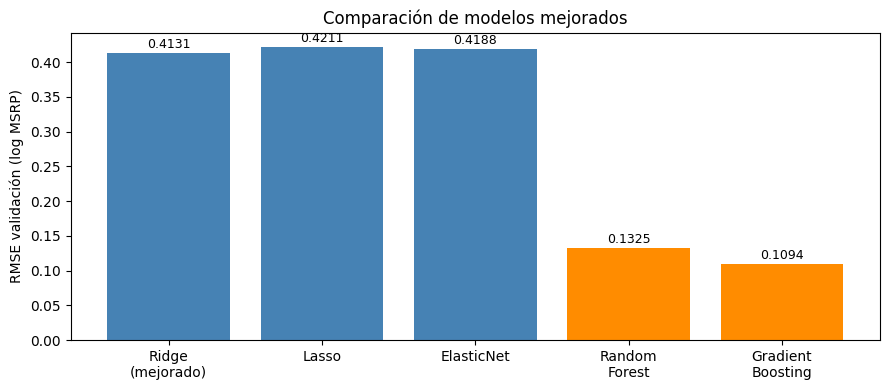

In [32]:
# Se crea un gráfico de barras para comparar visualmente el RMSE de validación de los modelos mejorados, destacando el modelo original de Ridge para mostrar la mejora obtenida.
modelos = ['Ridge\n(mejorado)', 'Lasso', 'ElasticNet', 'Random\nForest', 'Gradient\nBoosting']
scores  = [
    resultados['Ridge']['rmse_val'],
    resultados['Lasso']['rmse_val'],
    resultados['ElasticNet']['rmse_val'],
    rmse_rf_val,
    rmse_gb_val
]
# Se crea un gráfico de barras para comparar visualmente el RMSE de validación de los modelos mejorados, destacando el modelo original de Ridge para mostrar la mejora obtenida.
plt.figure(figsize=(9, 4))
bars = plt.bar(modelos, scores, color=['steelblue', 'steelblue', 'steelblue', 'darkorange', 'darkorange'])
plt.ylabel('RMSE validación (log MSRP)')
plt.title('Comparación de modelos mejorados')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()